In [1]:
import torch
from torchvision.models import resnet18
import torch.nn as nn

# Option 1: Using torchvision's pretrained models as feature extractors (encoder part)
def load_pretrained_encoder():
    # Load a pretrained ResNet but remove the final classification layer
    model = resnet18(pretrained=True)
    # Remove the final fully connected layer
    encoder = nn.Sequential(*list(model.children())[:-1])
    # This gives you a 512-dimensional feature vector for each image
    return encoder

# Option 2: Using pytorch-pretrained-vae package (if installed)
def load_pretrained_vae():
    try:
        import pytorch_pretrained_vae as vae_models
        model = vae_models.VAE_MNIST()  # For MNIST
        # Or other models like:
        # model = vae_models.VAE_CIFAR10()
        # model = vae_models.BetaVAE()
        return model
    except ImportError:
        print("pytorch_pretrained_vae package not installed.")
        return None

# Option 3: Using a torchvision-like API for pretrained models from HuggingFace
def load_stable_diffusion_vae():
    try:
        from diffusers import AutoencoderKL
        
        # Load the stable diffusion VAE
        vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse")
        return vae
    except ImportError:
        print("diffusers package not installed. Run 'pip install diffusers transformers'")
        return None

# For MNIST specifically - a much simpler approach with HuggingFace
def load_mnist_vae():
    try:
        from diffusers import AutoencoderKL
        # This is just an example path - you'd need the actual pretrained model path
        model_path = "fusing/vae-mnist"
        vae = AutoencoderKL.from_pretrained(model_path)
        return vae
    except (ImportError, OSError):
        print("Model not available or diffusers package not installed.")
        return None

# Example usage:
if __name__ == "__main__":
    # 1. If you want to use a pretrained CNN as an encoder
    encoder = load_pretrained_encoder()
    
    # 2. If you want a full VAE for MNIST
    vae = load_stable_diffusion_vae()
    
    # Example of encoding an image with Stable Diffusion VAE
    if vae is not None:
        # Create a random image batch (3, 512, 512)
        sample_image = torch.randn(1, 3, 512, 512)
        
        # Encode the image to latent space
        with torch.no_grad():
            latent = vae.encode(sample_image).latent_dist.sample()
            print(f"Latent shape: {latent.shape}")  # Should be [1, 4, 64, 64]
            
            # Decode back to image space
            decoded = vae.decode(latent).sample
            print(f"Decoded shape: {decoded.shape}")  # Should be [1, 3, 512, 512]

/home/bipar001/anaconda3/envs/wolfhusky/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bipar001/anaconda3/envs/wolfhusky/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/bipar001/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 28.4MB/s]
/home/bipar001/anaconda3/envs/wolfhusky/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please 

Latent shape: torch.Size([1, 4, 64, 64])
Decoded shape: torch.Size([1, 3, 512, 512])


In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load MNIST from OpenML
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data, mnist.target
X /= 255.0  

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9439285714285715


Accuracy: 0.9209


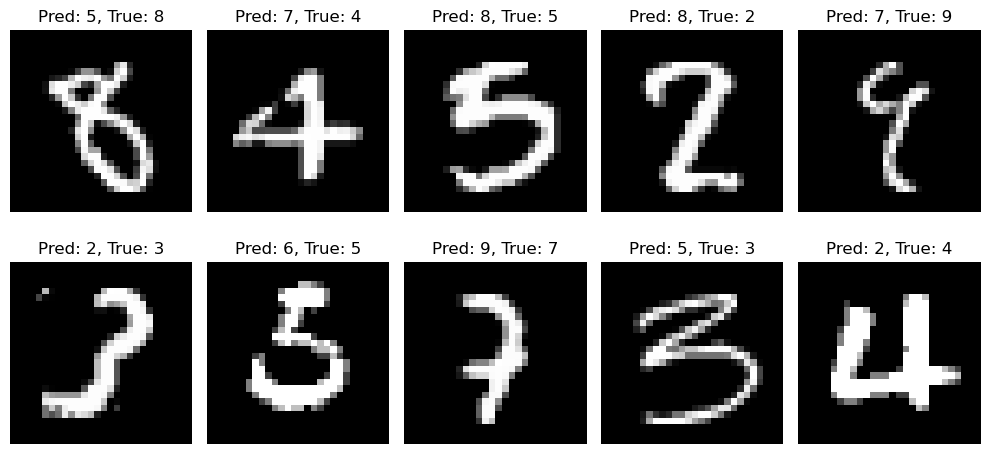

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load MNIST dataset from OpenML
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data, mnist.target.astype(int)  # Convert labels to integers

# Normalize pixel values to [0,1]
X /= 255.0  

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
clf = LogisticRegression(max_iter=1000, solver='lbfgs')
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Find misclassified examples
misclassified_indices = np.where(y_pred != y_test)[0]

# Visualize some misclassified images
num_images = 10  # Number of misclassified images to show
plt.figure(figsize=(10, 5))

for i, idx in enumerate(misclassified_indices[:num_images]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test.iloc[idx].values.reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {y_pred[idx]}, True: {y_test.iloc[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=len(trainset), shuffle=True)  # Full batch like sklearn
testloader = torch.utils.data.DataLoader(testset, batch_size=len(testset), shuffle=False)

# Define the logistic regression model (no hidden layers)
class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(28 * 28, 10)  # MNIST has 10 classes

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten image
        return self.linear(x)  # No activation (CrossEntropyLoss applies softmax)

# Initialize model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LogisticRegressionModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Similar to lbfgs behavior

# Training loop
num_epochs = 1000  # Matches sklearn's max_iter
for epoch in range(num_epochs):
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluate on test set
model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

# Compute accuracy
accuracy = (predicted == labels).float().mean().item()
print(f"Accuracy: {accuracy:.4f}")

# Identify misclassified examples
misclassified_indices = (predicted != labels).nonzero(as_tuple=True)[0]

# Visualize misclassified images
num_images = 10  # Show first 10 misclassified images
plt.figure(figsize=(10, 5))

for i, idx in enumerate(misclassified_indices[:num_images].cpu().numpy()):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[idx].cpu().view(28, 28), cmap="gray")
    plt.title(f"Pred: {predicted[idx].item()}, True: {labels[idx].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 873kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.01MB/s]


KeyboardInterrupt: 

Epoch [1/10], Loss: 0.6454
Epoch [2/10], Loss: 0.3677
Epoch [3/10], Loss: 0.3312
Epoch [4/10], Loss: 0.3140
Epoch [5/10], Loss: 0.3049
Epoch [6/10], Loss: 0.2983
Epoch [7/10], Loss: 0.2932
Epoch [8/10], Loss: 0.2896
Epoch [9/10], Loss: 0.2850
Epoch [10/10], Loss: 0.2827
Accuracy: 0.9224


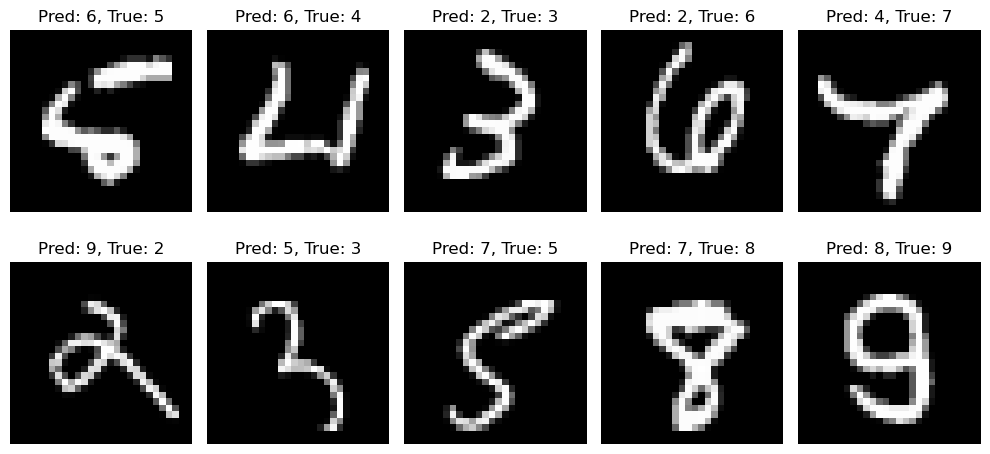

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)  # Use mini-batches
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False)

# Define the logistic regression model
class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(28 * 28, 10)  # MNIST has 10 classes

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten image
        return self.linear(x)  # No activation (CrossEntropyLoss applies softmax)

# Initialize model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LogisticRegressionModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam is better for small datasets

# Training loop (Reduced epochs + Mini-batches)
num_epochs = 10  # Faster training
for epoch in range(num_epochs):
    running_loss = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(trainloader):.4f}')

# Evaluate on test set
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.append(predicted)
        all_labels.append(labels)

# Convert predictions to a single tensor
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# Compute accuracy
accuracy = (all_preds == all_labels).float().mean().item()
print(f"Accuracy: {accuracy:.4f}")

# Identify misclassified examples
misclassified_indices = (all_preds != all_labels).nonzero(as_tuple=True)[0]

# Visualize misclassified images
num_images = 10  # Show first 10 misclassified images
plt.figure(figsize=(10, 5))

for i, idx in enumerate(misclassified_indices[:num_images].cpu().numpy()):
    plt.subplot(2, 5, i + 1)
    plt.imshow(testset.data[idx].cpu().numpy(), cmap="gray")
    plt.title(f"Pred: {all_preds[idx].item()}, True: {all_labels[idx].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False)

# Define the logistic regression model
class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(28 * 28, 10)  # MNIST has 10 classes

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten image
        return self.linear(x)  # No activation (CrossEntropyLoss applies softmax)

# Define the image transformation network
class ImageTransformNetwork(nn.Module):
    def __init__(self, hidden_dims=64):
        super(ImageTransformNetwork, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, hidden_dims, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(hidden_dims, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()  # Output in range [-1,1] to match normalization
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Wrapper model that combines transformer and classifier
class CombinedModel(nn.Module):
    def __init__(self, transformer, classifier):
        super(CombinedModel, self).__init__()
        self.transformer = transformer
        self.classifier = classifier
        
        # Freeze the classifier parameters
        for param in self.classifier.parameters():
            param.requires_grad = False
            
    def forward(self, x):
        transformed = self.transformer(x)
        return self.classifier(transformed), transformed

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize and train the logistic regression model
logistic_model = LogisticRegressionModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(logistic_model.parameters(), lr=0.001)

print("Training the logistic regression model...")
num_epochs = 10
for epoch in range(num_epochs):
    running_loss = 0
    for images, labels in tqdm(trainloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = logistic_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(trainloader):.4f}')

# Evaluate logistic regression model
logistic_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = logistic_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Base Logistic Regression Accuracy: {100 * correct / total:.2f}%')

# Now create and train the transformer network with the fixed logistic regression model
transform_net = ImageTransformNetwork().to(device)
combined_model = CombinedModel(transform_net, logistic_model).to(device)

# Define loss functions and optimizer
classification_criterion = nn.CrossEntropyLoss()
reconstruction_criterion = nn.MSELoss()
transform_optimizer = optim.Adam(transform_net.parameters(), lr=0.001)

# Hyperparameters for the combined loss
classification_weight = 1.0
reconstruction_weight = 0.4  # Small weight to keep transformed images somewhat recognizable

# Training loop for the transformer network
print("Training the transformer network...")
num_epochs = 20
for epoch in range(num_epochs):
    transform_net.train()
    running_loss = 0.0
    running_class_loss = 0.0
    running_recon_loss = 0.0
    
    for images, labels in tqdm(trainloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)
        
        transform_optimizer.zero_grad()
        
        # Forward pass through the combined model
        outputs, transformed_images = combined_model(images)
        
        # Calculate losses
        classification_loss = classification_criterion(outputs, labels)
        reconstruction_loss = reconstruction_criterion(transformed_images, images)
        
        # Combined loss
        total_loss = classification_weight * classification_loss + reconstruction_weight * reconstruction_loss
        
        # Backward and optimize
        total_loss.backward()
        transform_optimizer.step()
        
        running_loss += total_loss.item()
        running_class_loss += classification_loss.item()
        running_recon_loss += reconstruction_loss.item()
    
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Total Loss: {running_loss/len(trainloader):.4f}, '
          f'Classification Loss: {running_class_loss/len(trainloader):.4f}, '
          f'Reconstruction Loss: {running_recon_loss/len(trainloader):.4f}')

# Evaluate the combined model
combined_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs, _ = combined_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Enhanced Model Accuracy: {100 * correct / total:.2f}%')



Training the logistic regression model...


Epoch 1/10: 100%|██████████| 235/235 [00:09<00:00, 25.05it/s]


Epoch [1/10], Loss: 0.6550


Epoch 2/10: 100%|██████████| 235/235 [00:10<00:00, 22.73it/s]


Epoch [2/10], Loss: 0.3694


...

Epoch [18/20], Total Loss: 0.0799, Classification Loss: 0.0494, Reconstruction Loss: 0.0762


Epoch 19/20: 100%|██████████| 235/235 [00:43<00:00,  5.39it/s]


Epoch [19/20], Total Loss: 0.0759, Classification Loss: 0.0455, Reconstruction Loss: 0.0760


Epoch 20/20: 100%|██████████| 235/235 [00:43<00:00,  5.37it/s]


Epoch [20/20], Total Loss: 0.0723, Classification Loss: 0.0422, Reconstruction Loss: 0.0755
Enhanced Model Accuracy: 97.77%


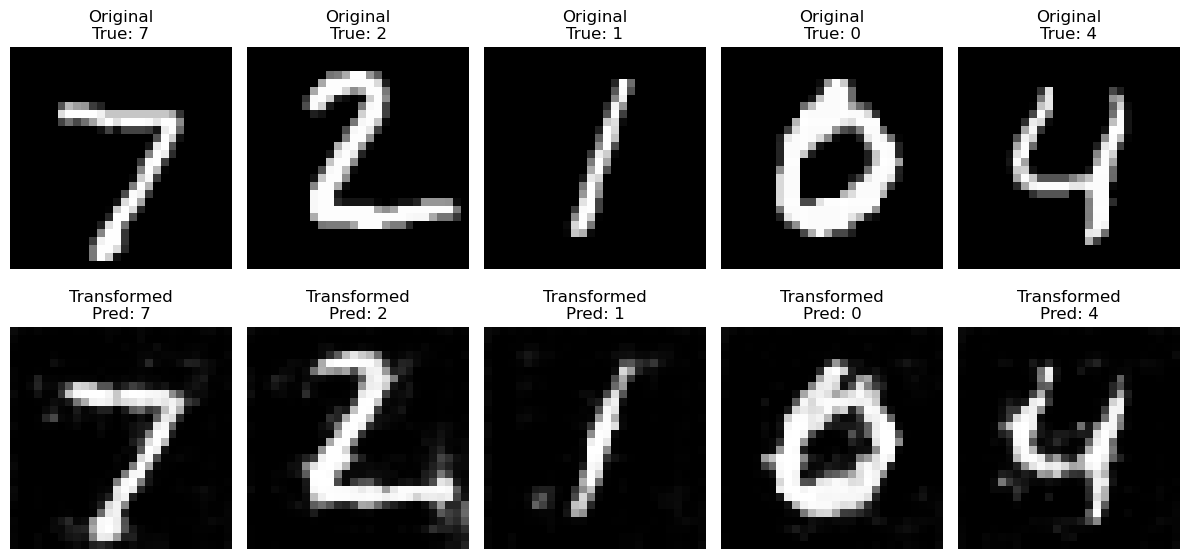

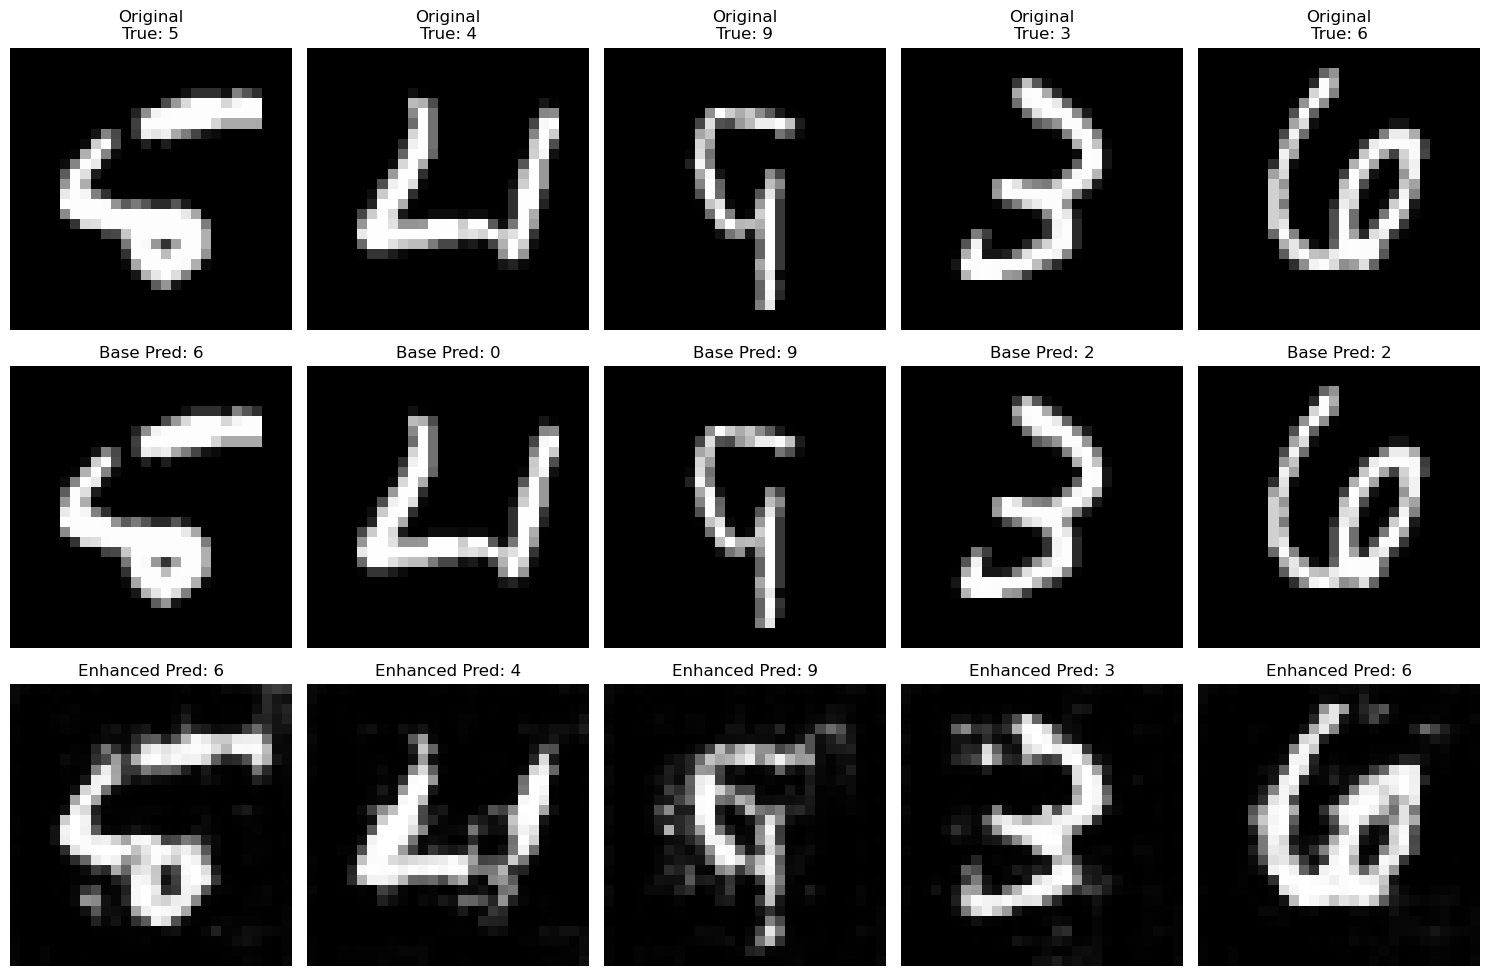

In [10]:
# Visualize original vs transformed images
def visualize_transformation(images, transformed_images, predictions, labels):
    plt.figure(figsize=(12, 6))
    num_images = min(5, images.size(0))
    
    for i in range(num_images):
        # Original image
        plt.subplot(2, num_images, i + 1)
        plt.imshow(images[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Original\nTrue: {labels[i].item()}")
        plt.axis('off')
        
        # Transformed image
        plt.subplot(2, num_images, i + num_images + 1)
        plt.imshow(transformed_images[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Transformed\nPred: {predictions[i].item()}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Get some test images
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Get transformed images and predictions
with torch.no_grad():
    outputs, transformed_images = combined_model(images)
    _, predictions = torch.max(outputs, 1)

# Denormalize images for visualization (from [-1,1] to [0,1])
images_viz = (images * 0.5) + 0.5
transformed_viz = (transformed_images * 0.5) + 0.5

# Visualize
visualize_transformation(images_viz[:5], transformed_viz[:5], predictions[:5], labels[:5])

# Analyze improvement on difficult examples
# First find difficult examples using the base logistic model
logistic_model.eval()
difficult_images = []
difficult_labels = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = logistic_model(images)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        max_probs, predictions = torch.max(probabilities, 1)
        
        # Find examples where model is uncertain (low probability) or wrong
        difficult_mask = (max_probs < 0.7) | (predictions != labels)
        if difficult_mask.any():
            difficult_images.append(images[difficult_mask])
            difficult_labels.append(labels[difficult_mask])
            
            # Just get a few examples
            if len(difficult_images) >= 5:
                break

if difficult_images:
    # Concatenate the tensors
    difficult_images = torch.cat(difficult_images[:5])
    difficult_labels = torch.cat(difficult_labels[:5])
    
    # Get transformed images and predictions for difficult examples
    with torch.no_grad():
        logistic_outputs = logistic_model(difficult_images)
        _, logistic_preds = torch.max(logistic_outputs, 1)
        
        combined_outputs, transformed_difficult = combined_model(difficult_images)
        _, combined_preds = torch.max(combined_outputs, 1)
    
    # Visualize improvement on difficult examples
    plt.figure(figsize=(15, 10))
    
    for i in range(min(5, difficult_images.size(0))):
        # Original image
        plt.subplot(3, 5, i + 1)
        plt.imshow((difficult_images[i] * 0.5 + 0.5).cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Original\nTrue: {difficult_labels[i].item()}")
        plt.axis('off')
        
        # Logistic prediction
        plt.subplot(3, 5, i + 6)
        plt.imshow((difficult_images[i] * 0.5 + 0.5).cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Base Pred: {logistic_preds[i].item()}")
        correct = "✓" if logistic_preds[i] == difficult_labels[i] else "✗"
        plt.xlabel(f"Correct: {correct}")
        plt.axis('off')
        
        # Transformed image with prediction
        plt.subplot(3, 5, i + 11)
        plt.imshow((transformed_difficult[i] * 0.5 + 0.5).cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Enhanced Pred: {combined_preds[i].item()}")
        correct = "✓" if combined_preds[i] == difficult_labels[i] else "✗"
        plt.xlabel(f"Correct: {correct}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

Finding examples where the transformation network improved classification...


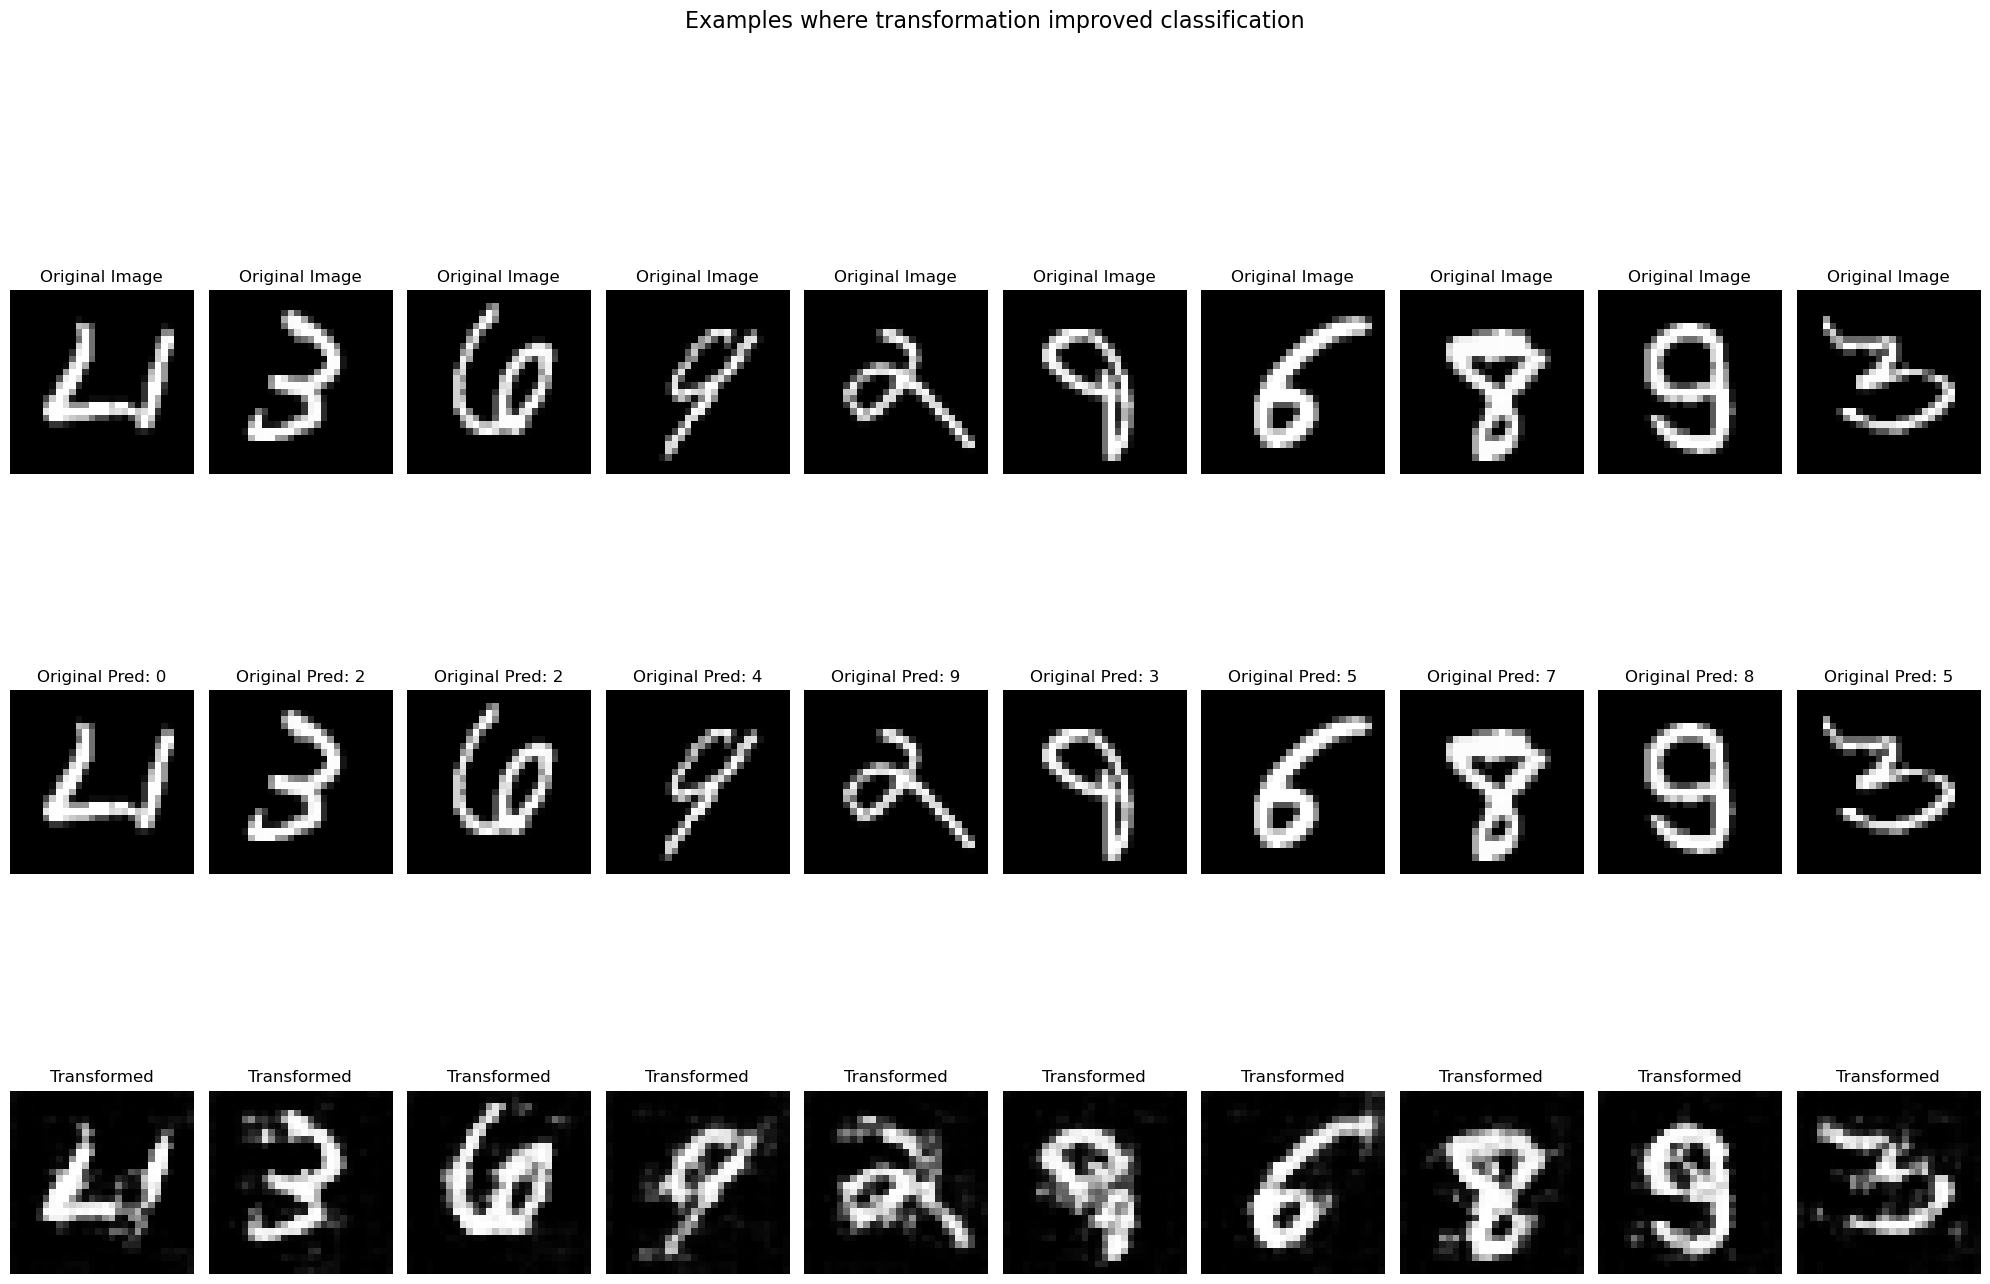

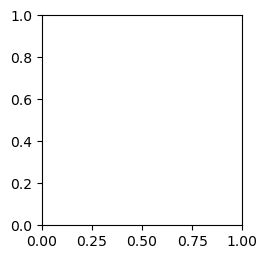

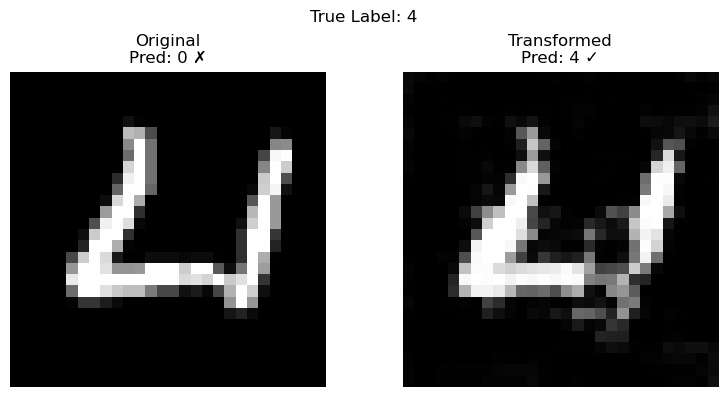

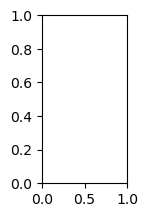

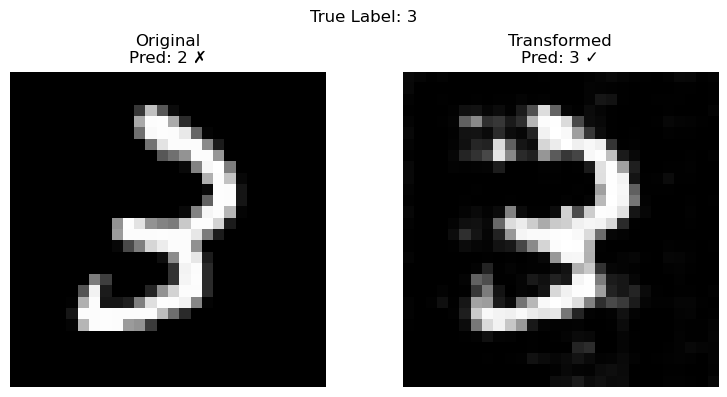

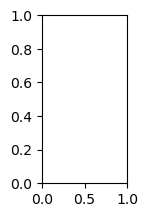

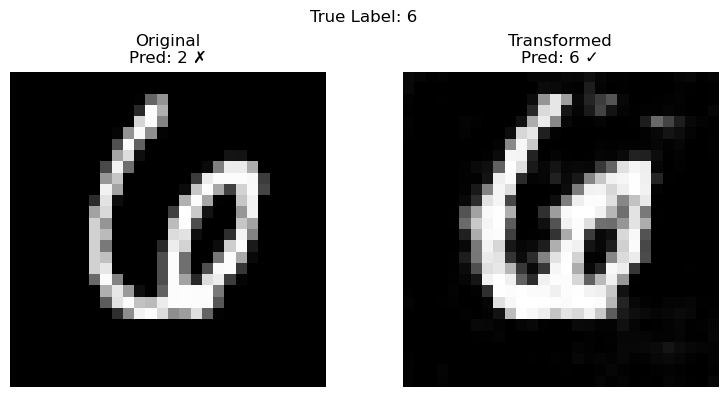

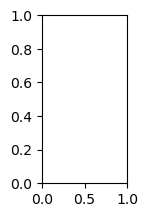

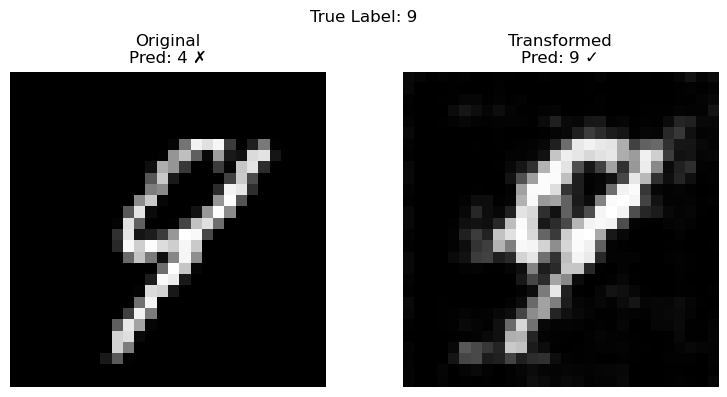

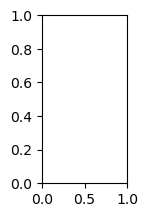

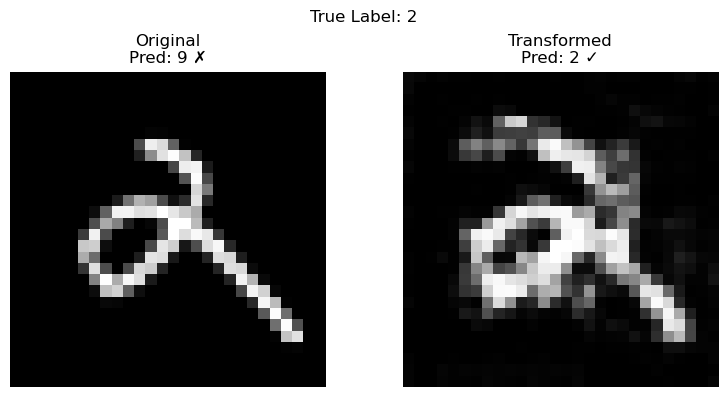

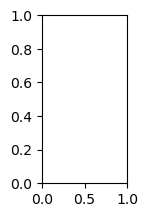

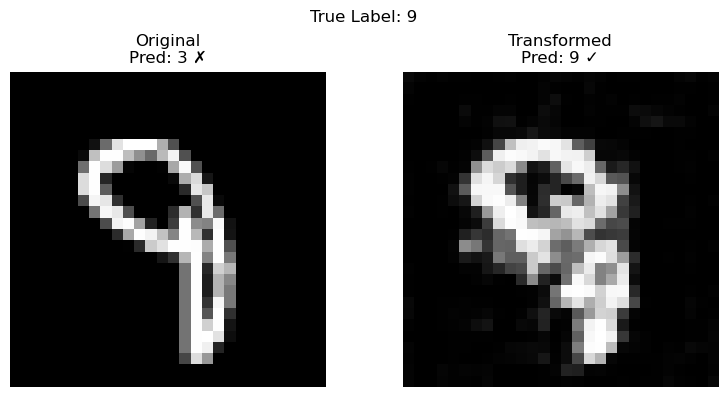

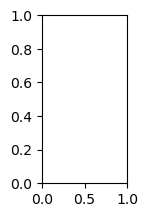

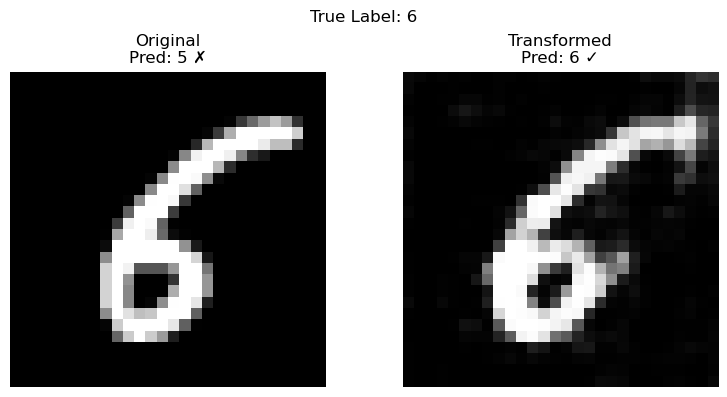

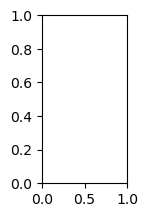

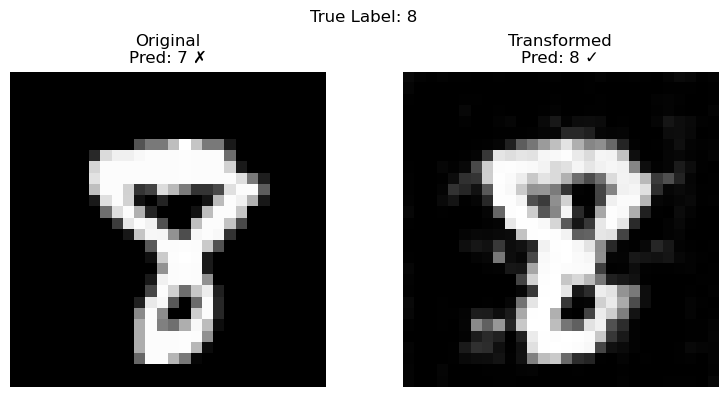

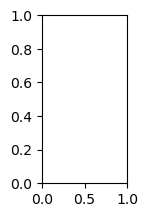

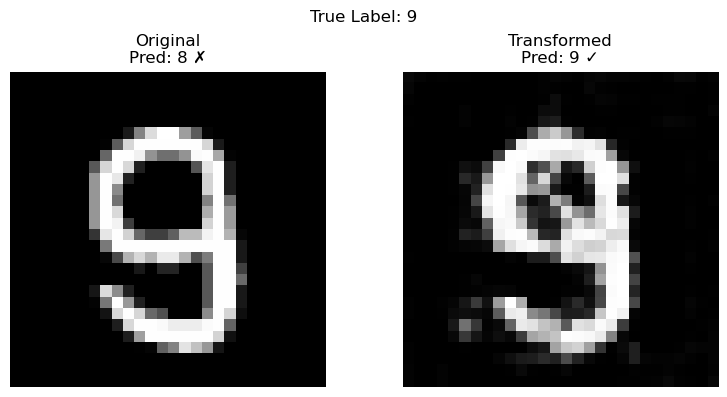

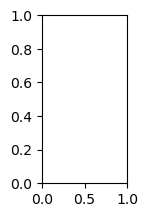

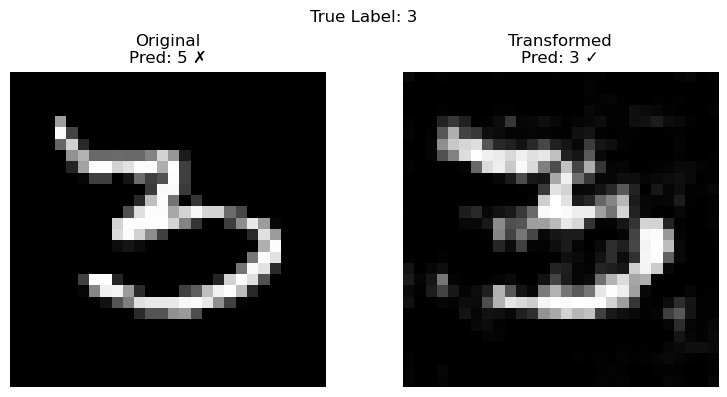

In [11]:
# Code to find and visualize examples where the transformation improved classification
def find_improved_examples(original_model, combined_model, test_loader, num_examples=10):
    original_model.eval()
    combined_model.eval()
    
    improved_images = []
    true_labels = []
    original_preds = []
    improved_preds = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Get predictions from original model
            original_outputs = original_model(images)
            _, original_predictions = torch.max(original_outputs, 1)
            
            # Get predictions from combined model
            combined_outputs, transformed_images = combined_model(images)
            _, combined_predictions = torch.max(combined_outputs, 1)
            
            # Find examples where original model was wrong but combined model is correct
            improved_mask = (original_predictions != labels) & (combined_predictions == labels)
            
            if improved_mask.any():
                improved_images.append((images[improved_mask], transformed_images[improved_mask]))
                true_labels.append(labels[improved_mask])
                original_preds.append(original_predictions[improved_mask])
                improved_preds.append(combined_predictions[improved_mask])
            
            # Check if we have enough examples
            total_found = sum(len(batch) for batch in true_labels)
            if total_found >= num_examples:
                break
    
    # Combine the first num_examples
    selected_images = []
    selected_transformed = []
    selected_labels = []
    selected_original_preds = []
    selected_improved_preds = []
    
    examples_needed = num_examples
    for i in range(len(true_labels)):
        batch_size = len(true_labels[i])
        take = min(examples_needed, batch_size)
        
        selected_images.append(improved_images[i][0][:take])
        selected_transformed.append(improved_images[i][1][:take])
        selected_labels.append(true_labels[i][:take])
        selected_original_preds.append(original_preds[i][:take])
        selected_improved_preds.append(improved_preds[i][:take])
        
        examples_needed -= take
        if examples_needed <= 0:
            break
    
    # Concatenate all selected examples
    if selected_images:
        selected_images = torch.cat(selected_images)
        selected_transformed = torch.cat(selected_transformed)
        selected_labels = torch.cat(selected_labels)
        selected_original_preds = torch.cat(selected_original_preds)
        selected_improved_preds = torch.cat(selected_improved_preds)
        
        return selected_images, selected_transformed, selected_labels, selected_original_preds, selected_improved_preds
    else:
        return None

# Find examples where transformation improved classification
print("Finding examples where the transformation network improved classification...")
improved_data = find_improved_examples(logistic_model, combined_model, testloader, num_examples=10)

if improved_data:
    images, transformed_images, true_labels, original_preds, improved_preds = improved_data
    
    # Denormalize images for visualization (from [-1,1] to [0,1])
    images_viz = (images * 0.5) + 0.5
    transformed_viz = (transformed_images * 0.5) + 0.5
    
    # Visualize the improved examples
    plt.figure(figsize=(20, 15))
    
    for i in range(min(10, images.size(0))):
        # Original image with incorrect prediction
        plt.subplot(3, 10, i + 1)
        plt.imshow(images_viz[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Original Image")
        plt.axis('off')
        
        # Original prediction (incorrect)
        plt.subplot(3, 10, i + 11)
        plt.imshow(images_viz[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Original Pred: {original_preds[i].item()}")
        plt.xlabel(f"True Label: {true_labels[i].item()}")
        plt.axis('off')
        
        # Transformed image with correct prediction
        plt.subplot(3, 10, i + 21)
        plt.imshow(transformed_viz[i].cpu().squeeze().numpy(), cmap='gray')
        plt.title(f"Transformed")
        plt.xlabel(f"Pred: {improved_preds[i].item()} ✓")
        plt.axis('off')
    
    plt.suptitle("Examples where transformation improved classification", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    
    # Additional detailed 2x5 grid visualization
    plt.figure(figsize=(15, 6))
    for i in range(min(10, images.size(0))):
        plt.subplot(2, 5, i + 1)
        
        # Create a side-by-side comparison
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
        
        # Original image
        ax1.imshow(images_viz[i].cpu().squeeze().numpy(), cmap='gray')
        ax1.set_title(f"Original\nPred: {original_preds[i].item()} ✗")
        ax1.axis('off')
        
        # Transformed image
        ax2.imshow(transformed_viz[i].cpu().squeeze().numpy(), cmap='gray')
        ax2.set_title(f"Transformed\nPred: {improved_preds[i].item()} ✓")
        ax2.axis('off')
        
        plt.suptitle(f"True Label: {true_labels[i].item()}")
        plt.tight_layout()
        plt.show()
else:
    print("Could not find enough examples where transformation improved classification.")
    print("This could mean either the original model is already very accurate or the transformation did not help significantly.")
    print("Try running the training for more epochs or adjusting the transformation network architecture.")